# Building DSpark: faster LLM decoding, losslessly

[**DSpark**](https://huggingface.co/deepseek-ai/DeepSeek-V4-Pro-DSpark) is the speculative-decoding
drafter that recently ships with DeepSeek-V4. It is striking how little it adds — a small "block" drafter, a
low-rank bias, and a one-number confidence score — yet it makes a real model generate text noticeably
faster **without changing the output at all**. This notebook rebuilds DSpark from scratch, loads
DeepSeek's released weights into our own code to confirm it is faithful, and measures the speedup.

**Why decoding is slow.** A language model writes one token at a time. To produce *each* token it has
to read *all* of its billions of weights out of GPU memory — a huge amount of work for a single word,
with the arithmetic units mostly waiting on memory. **Speculative decoding** turns that waste into
speed: a small *draft* model guesses a few tokens ahead, the big *target* model checks the whole guess
in one shot, and a careful rule keeps the result identical to normal decoding. DSpark's twist is to
make the *draft* fast too — it proposes a whole block of tokens in a single pass.

**Prerequisites:** If you know what a transformer is and have seen an LLM generate text, you have enough background. Every idea is introduced right where it is first needed.

**Runs on a free GPU.** The whole notebook fits on a **Google Colab T4 (16 GB)**: we keep at most two
models in memory at once (~11 GB) and use half precision. On Colab: *Runtime → Change runtime type →
T4 GPU*, then run top to bottom.

## 0. Setup

**Precision:** newer GPUs (A100/H100/GB200) have fast
`bfloat16`; the T4 does not, so we fall back to `float16` there — both are 16-bit, so the memory
budget is the same. **Length:** we cap generations at `MAX_NEW` tokens so a T4 stays responsive.

In [1]:
import time, gc, os
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, DynamicCache
from transformers.models.qwen3.modeling_qwen3 import (
    Qwen3MLP, Qwen3RMSNorm, Qwen3RotaryEmbedding, rotate_half,
)
import transformers
transformers.logging.set_verbosity_error()
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
    transformers.utils.logging.disable_progress_bar()
except Exception:
    pass

os.makedirs("assets", exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    raise RuntimeError(
        "This notebook needs a CUDA GPU — a 4B model is impractically slow on CPU. "
        "On Google Colab: Runtime -> Change runtime type -> T4 GPU, then run again."
    )
# bf16 on Ampere+ (A100/H100/GB200); fp16 on the T4 and other pre-Ampere GPUs.
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
if os.environ.get("DSPARK_DTYPE"):                 # optional override, e.g. to force fp16
    DTYPE = getattr(torch, os.environ["DSPARK_DTYPE"])
MAX_NEW = 96                                        # tokens per generation (small keeps a T4 snappy)

# optional: emulate a smaller GPU (e.g. set DSPARK_MEM_CAP_GB=15 to test a 16 GB T4 budget)
_cap = os.environ.get("DSPARK_MEM_CAP_GB")
if _cap:
    torch.cuda.set_per_process_memory_fraction(
        float(_cap) / (torch.cuda.get_device_properties(0).total_memory / 1e9), 0)

torch.manual_seed(0)
print(f"device = {DEVICE}  |  dtype = {str(DTYPE).split('.')[-1]}  |  {torch.cuda.get_device_name()}")
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

def gpu_mem() -> str:
    return f"{torch.cuda.memory_allocated() / 1e9:.1f} GB in use"

device = cuda  |  dtype = bfloat16  |  NVIDIA GB200
VRAM total: 197.9 GB


In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, x, y, w, h, text, fc="#eaf0fb", ec="#3b5b92", tc="#14203a", fs=10, lw=1.4):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.015,rounding_size=0.08",
                                linewidth=lw, facecolor=fc, edgecolor=ec))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc)

def arrow(ax, x0, y0, x1, y1, color="#3b5b92", lw=1.5, style="-|>"):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle=style,
                                 mutation_scale=12, color=color, lw=lw))

def blank(ax, xlim=(0, 10), ylim=(0, 4)):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")

GREEN, RED, GREY, BLUE = "#d7efd7", "#f6d4d4", "#e6e6e6", "#dbe6fb"

## 1. How an LLM decodes, and why it's slow

An LLM reads a sequence of tokens and outputs a vector of scores — **logits** — one score per word in
its vocabulary. Greedy decoding just takes the highest-scoring token (the `argmax`), appends it, and
repeats. To avoid recomputing the whole history each step, the model caches the per-layer keys and
values it already computed (the **KV cache**), so each new token costs a single forward pass over just
that one token.

The catch: that one forward pass still has to **read every weight in the model** from GPU memory. At
batch size 1 we stream billions of parameters to produce a single token, and the GPU's math units sit
idle waiting on memory. Picture it as one heavy pass per token:

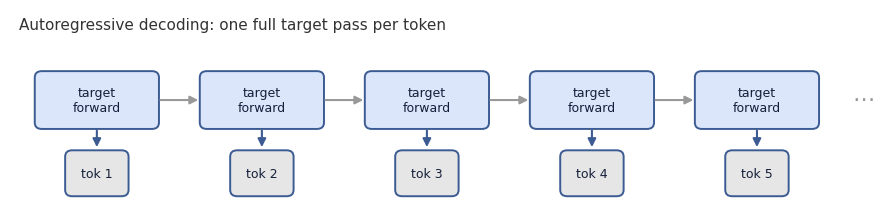

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.2)); blank(ax, (0, 10), (0, 2.4))
ax.text(0.1, 2.15, "Autoregressive decoding: one full target pass per token", fontsize=11, color="#333")
for i in range(5):
    x = 0.3 + i * 1.9
    box(ax, x, 0.9, 1.4, 0.7, "target\nforward", fc=BLUE, fs=9)
    box(ax, x + 0.35, 0.05, 0.7, 0.55, f"tok {i+1}", fc=GREY, fs=9)
    arrow(ax, x + 0.7, 0.9, x + 0.7, 0.62)
    if i < 4:
        arrow(ax, x + 1.4, 1.25, x + 1.9, 1.25, color="#999")
ax.text(9.7, 1.25, "…", fontsize=16, color="#999")
plt.tight_layout(); plt.savefig("assets/fig_ar_timeline.png", dpi=110); plt.show()

We load the model we'll speed up — **Qwen3-4B** — and measure plain greedy decoding as our
baseline. (First run downloads a few GB.)

In [4]:
TARGET_NAME = "Qwen/Qwen3-4B"
target = AutoModelForCausalLM.from_pretrained(
    TARGET_NAME, dtype=DTYPE, attn_implementation="sdpa"
).to(DEVICE).eval()
tok = AutoTokenizer.from_pretrained(TARGET_NAME)

EOS = target.generation_config.eos_token_id
STOP = set(EOS if isinstance(EOS, list) else [EOS])
print(f"loaded {TARGET_NAME}: {sum(p.numel() for p in target.parameters())/1e9:.1f}B params "
      f"| {target.config.num_hidden_layers} layers | {gpu_mem()}")

def chat_ids(user: str) -> torch.Tensor:
    # DSpark's released draft was trained in Qwen's "non-thinking" mode, so we match it.
    msgs = [{"role": "user", "content": user}]
    return tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt",
                                   return_dict=True, enable_thinking=False)["input_ids"].to(DEVICE)

loaded Qwen/Qwen3-4B: 4.0B params | 36 layers | 8.1 GB in use


Greedy decoding is the loop we described: forward pass → take the `argmax` → append → repeat, reusing
the KV cache each step.

In [5]:
@torch.inference_mode()
def greedy_ar(model, input_ids, max_new=MAX_NEW, _timing=None):
    if _timing is not None:
        torch.cuda.synchronize(); _t0 = time.time()
    cache = DynamicCache()
    n_in = input_ids.shape[1]
    out = model(input_ids=input_ids, position_ids=torch.arange(n_in, device=DEVICE)[None],
                past_key_values=cache, use_cache=True)               # prefill: read the whole prompt
    nxt = out.logits[:, -1].argmax(-1, keepdim=True)                 # first token (a prefill by-product)
    toks, cur = [int(nxt)], n_in
    if _timing is not None:
        torch.cuda.synchronize(); _timing["prefill_s"] = time.time() - _t0; _t1 = time.time()
    while len(toks) < max_new:                                       # decode: one target pass per token
        out = model(input_ids=nxt, position_ids=torch.arange(cur, cur + 1, device=DEVICE)[None],
                    past_key_values=cache, use_cache=True)
        nxt = out.logits[:, -1].argmax(-1, keepdim=True)
        toks.append(int(nxt)); cur += 1
        if int(nxt) in STOP:
            break
    if _timing is not None:
        torch.cuda.synchronize()
        _timing["decode_s"] = time.time() - _t1; _timing["decoded"] = len(toks) - 1
    return toks

**A note on "tokens per second."** The first forward pass is special: it reads the *whole prompt* at
once and yields the first token. That's **prefill** — a one-time cost, your *time to first token*.
Everything after is **decode**: one pass per token. Speculative decoding accelerates only the decode
phase, so we time that phase and quote prefill separately. (Folding a fixed prefill into the rate would
quietly drag every method's number toward the others.)

In [6]:
ids = chat_ids("In one short paragraph, explain why the sky is blue.")
greedy_ar(target, ids, max_new=8)                        # warm up CUDA kernels
tm = {}
ar_toks = greedy_ar(target, ids, _timing=tm)
BASE = {"AR tok/s": tm["decoded"] / tm["decode_s"]}
print(f"prefill (time to first token): {tm['prefill_s'] * 1000:.0f} ms")
print(f"decode: {tm['decoded']} tokens in {tm['decode_s']:.2f}s = {BASE['AR tok/s']:.1f} tok/s")
print(tok.decode(ar_toks))

prefill (time to first token): 40 ms
decode: 63 tokens in 4.11s = 15.3 tok/s
The sky appears blue because molecules in the Earth's atmosphere scatter shorter wavelengths of light, like blue, more efficiently than longer wavelengths, such as red. When sunlight enters the atmosphere, these blue light waves are scattered in all directions by gas molecules and small particles, making the sky look blue to observers on the ground.<|im_end|>


That rate — one heavy pass per token — is our baseline. The per-token latency of *any* speculative
scheme is

$$ L = \frac{T_{\text{draft}} + T_{\text{verify}}}{\tau}, $$

where $\tau$ (the **acceptance length**) is how many tokens we manage to commit per cycle. The formula
names the three ways to win: draft cheaper, draft better (bigger $\tau$), or verify smarter. Next we
build the machinery that makes committing several tokens per target pass *safe*.

## 2. Speculative decoding: the idea

Suppose a cheap **draft** hands us a few guessed tokens. Their positions are now fixed, so the
**target** can score all of them in a *single* forward pass — the same memory read that used to buy one
token now checks several. We keep the longest guessed prefix the target agrees with, plus one free
"bonus" token. One target pass, several tokens:

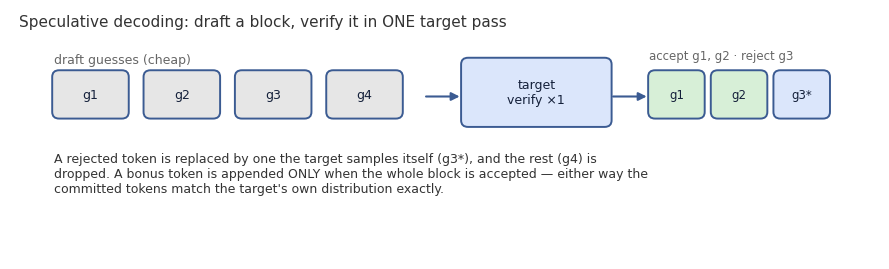

In [7]:
fig, ax = plt.subplots(figsize=(9, 2.8)); blank(ax, (0, 10), (0, 3))
ax.text(0.1, 2.8, "Speculative decoding: draft a block, verify it in ONE target pass", fontsize=11, color="#333")
for i, t in enumerate(["g1", "g2", "g3", "g4"]):                  # draft guesses
    box(ax, 0.5 + i * 1.05, 1.7, 0.85, 0.55, t, fc=GREY, fs=9)
ax.text(0.5, 2.35, "draft guesses (cheap)", fontsize=9, color="#666")
box(ax, 5.2, 1.6, 1.7, 0.8, "target\nverify ×1", fc=BLUE, fs=9)
arrow(ax, 4.75, 1.95, 5.2, 1.95)
arrow(ax, 6.9, 1.95, 7.35, 1.95)
for i, (t, c) in enumerate([("g1", GREEN), ("g2", GREEN), ("g3*", BLUE)]):
    box(ax, 7.35 + i * 0.72, 1.7, 0.62, 0.55, t, fc=c, fs=8.5)
ax.text(7.35, 2.4, "accept g1, g2 · reject g3", fontsize=8.5, color="#666")
ax.text(0.5, 0.8, "A rejected token is replaced by one the target samples itself (g3*), and the rest (g4) is\n"
        "dropped. A bonus token is appended ONLY when the whole block is accepted — either way the\n"
        "committed tokens match the target's own distribution exactly.",
        fontsize=9, color="#333")
plt.tight_layout(); plt.savefig("assets/fig_spec_timeline.png", dpi=110); plt.show()

**The rule.** It is short (Leviathan et al.,
[2023](https://arxiv.org/abs/2211.17192); Chen et al., [2023](https://arxiv.org/abs/2302.01318)).
Write $p^d$ for the draft's probability of a token and $p^t$ for the target's, and walk left to right
through the block:

1. **Accept** the guessed token with probability $\min\!\big(1,\ p^t / p^d\big)$ — always, if the
   target likes it at least as much as the draft did; otherwise accept only sometimes.
2. **On the first rejection, correct and stop.** Replace that position with a single draw from the
   *leftover* distribution: for every token take $\big(p^t - p^d\big)_+$ — the probability the target
   wanted *beyond* what the draft supplied, with negatives clipped to zero — then renormalize it to
   sum to 1 and sample once. That corrected token is committed as-is (it is *not* checked again), and
   every draft token after it is discarded.
3. **If the whole block survives, add a bonus.** With no rejection, draw one extra token straight from
   the target — a free token for the round.

**Why it's lossless.** Call a token *over-drafted* when the draft proposes it more
than the target wants ($p^d > p^t$) and *under-drafted* when less ($p^d < p^t$). Acceptance keeps a
proposal with probability $\min(1, p^t/p^d)$, so under-drafted tokens (accept probability $1$) are
*never* rejected, while over-drafted ones are rejected just often enough to shed their excess — and
that shed mass isn't lost: the leftover $\big(p^t - p^d\big)_+$ is supported exactly on the
under-drafted tokens, so each rejection *recycles* the freed probability to whoever the draft
shortchanged. Per token the two routes add up — acceptance gives $\min(p^d, p^t)$, the leftover gives
$\big(p^t - p^d\big)_+$, and $\min(p^d, p^t) + \big(p^t - p^d\big)_+ = p^t$ — so the emitted token is
distributed *exactly* as the target would sample it, and the correction is committed without a second
check. (Concretely, with $p^d=(0.8,\,0.2)$ and $p^t=(0.5,\,0.5)$: the over-drafted $A$ shows up $0.5$
of the time through acceptance; rejecting its excess frees $0.3$, which the leftover hands entirely to
the under-drafted $B$, lifting it $0.2\to0.5$.)

We'll run everything at temperature 0 (greedy), where this collapses to something you can eyeball:
*accept a guess while it equals the target's `argmax`; the first mismatch is replaced by the target's
`argmax`* — at temperature 0 the leftover distribution is just the target's one-hot. That makes runs
easy to check, so we implement the general rule and test it in greedy mode. Here is the whole verifier
— small enough to read in one sitting.

In [8]:
def to_probs(logits, temperature):
    # temperature 0 -> a one-hot "distribution" at the argmax; otherwise softmax(logits / T)
    if temperature < 1e-5:
        p = torch.zeros_like(logits, dtype=torch.float32)
        p.scatter_(-1, logits.argmax(-1, keepdim=True), 1.0)
        return p
    return torch.softmax(logits.float() / temperature, dim=-1)

def verify(target_probs, draft_tokens, draft_probs):
    # target_probs: [gamma+1, V] target dist at each slot; draft_tokens: [gamma]; draft_probs: [gamma, V]
    # returns (num_accepted, bonus_or_correction_token)
    gamma = draft_tokens.shape[0]
    n_acc = 0
    for k in range(gamma):
        xk = int(draft_tokens[k])
        pt = float(target_probs[k, xk]); pd = float(draft_probs[k, xk].clamp_min(1e-8))
        if float(torch.rand(())) < min(1.0, pt / pd):
            n_acc += 1
        else:
            break
    if n_acc < gamma:                                     # first rejection -> resample the leftover
        leftover = (target_probs[n_acc] - draft_probs[n_acc]).clamp_min(0.0)
        leftover = leftover / leftover.sum().clamp_min(1e-8)
        token = int(torch.multinomial(leftover, 1))
    else:                                                 # whole block accepted -> free bonus token
        token = int(torch.multinomial(target_probs[gamma], 1))
    return n_acc, token

## 3. A first speculative decoder (with a small AR draft)

The simplest possible draft is just a *smaller model from the same family*. **Qwen3-0.6B** shares
Qwen3-4B's tokenizer, so it can propose tokens the 4B model understands. It drafts the way any LLM
does — one token at a time — then the 4B target verifies the block in one pass. This is textbook
speculative decoding; we use it to make the loop concrete (and as a baseline) before DSpark.

In [9]:
small = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B", dtype=DTYPE, attn_implementation="sdpa"
).to(DEVICE).eval()
print(f"loaded draft Qwen3-0.6B | {gpu_mem()}")

loaded draft Qwen3-0.6B | 9.3 GB in use


We start by **prefilling** both models on the prompt — one forward each, which fills their KV caches
(and the target's forward also emits the first token, our initial `anchor`). After that each cycle is
cheap: the small model autoregressively drafts $\gamma$ tokens, the target scores the whole block in
one pass, and `verify` decides how many to keep. Note how `anchor` (the last committed token) seeds
each block, and how both caches are cropped back to the accepted length so nothing rejected lingers.

In [10]:
@torch.inference_mode()
def spec_decode_ar(target, draft, input_ids, gamma=4, temperature=0.0, max_new=MAX_NEW, _timing=None):
    if _timing is not None:
        torch.cuda.synchronize(); _t0 = time.time()
    tcache, dcache = DynamicCache(), DynamicCache()
    n_in = input_ids.shape[1]
    out = target(input_ids=input_ids, position_ids=torch.arange(n_in, device=DEVICE)[None],
                 past_key_values=tcache, use_cache=True)              # prefill target: fill cache + emit token 1
    draft(input_ids=input_ids, position_ids=torch.arange(n_in, device=DEVICE)[None],
          past_key_values=dcache, use_cache=True)                    # prefill draft: fill its own cache (logits unused)
    anchor = out.logits[:, -1].argmax(-1, keepdim=True)              # first committed token comes from the TARGET
    committed, accept_lens, start = [int(anchor)], [], n_in
    if _timing is not None:
        torch.cuda.synchronize(); _timing["prefill_s"] = time.time() - _t0; _t1 = time.time()
    while len(committed) < max_new:
        d_tokens, d_probs, cur, cpos = [], [], anchor, start          # draft gamma tokens one by one
        for _ in range(gamma):
            do = draft(input_ids=cur, position_ids=torch.arange(cpos, cpos + 1, device=DEVICE)[None],
                       past_key_values=dcache, use_cache=True)
            p = to_probs(do.logits[:, -1], temperature)[0]
            t = p.argmax() if temperature < 1e-5 else torch.multinomial(p, 1)[0]
            d_tokens.append(int(t)); d_probs.append(p); cur = t.view(1, 1); cpos += 1
        verify_ids = torch.tensor([[int(anchor)] + d_tokens], device=DEVICE)   # target scores block ×1
        vout = target(input_ids=verify_ids,
                      position_ids=torch.arange(start, start + gamma + 1, device=DEVICE)[None],
                      past_key_values=tcache, use_cache=True)
        tp = to_probs(vout.logits[0], temperature)
        n_acc, bonus = verify(tp, torch.tensor(d_tokens), torch.stack(d_probs))
        committed += d_tokens[:n_acc] + [bonus]
        accept_lens.append(n_acc + 1); start += n_acc + 1
        tcache.crop(start); dcache.crop(start)                          # forget rejected tokens
        anchor = torch.tensor([[bonus]], device=DEVICE)
        if bonus in STOP:
            break
    if _timing is not None:
        torch.cuda.synchronize()
        _timing["decode_s"] = time.time() - _t1; _timing["decoded"] = len(committed) - 1
    return committed, accept_lens

We run it and measure $\tau$ — the average tokens committed per target pass. Across a few prompts
(math, code, chat) we also record the per-domain $\tau$ to compare against DSpark later.

In [11]:
PROMPTS = {
    "math": "Compute 1+2+...+100 and explain the formula in two sentences.",
    "code": "Write a Python function is_palindrome(s) and briefly explain it.",
    "chat": "Give three tips for staying focused while working.",
}
PROMPT_IDS = {k: chat_ids(v) for k, v in PROMPTS.items()}

ar_draft_tau = {}
for name, pid in PROMPT_IDS.items():
    _, acc = spec_decode_ar(target, small, pid, gamma=4)
    ar_draft_tau[name] = float(np.mean(acc))
tm = {}
sp_toks, _ = spec_decode_ar(target, small, ids, gamma=4, _timing=tm)
BASE["AR-draft tok/s"] = tm["decoded"] / tm["decode_s"]
BASE["AR-draft tau"] = ar_draft_tau
print("AR-draft tau by prompt:", {k: round(v, 2) for k, v in ar_draft_tau.items()})
print(f"AR-draft speed: {BASE['AR-draft tok/s']:.1f} tok/s  (plain greedy was {BASE['AR tok/s']:.1f})")

AR-draft tau by prompt: {'math': 2.3, 'code': 3.06, 'chat': 2.4}
AR-draft speed: 13.1 tok/s  (plain greedy was 15.3)


Two things stand out. First, $\tau > 1$: we really are committing multiple tokens per target pass.
Second — and maybe surprisingly — the wall-clock speed may be **no better** (sometimes worse) than
plain decoding. The reason is the draft's own cost: a strong autoregressive draft runs $\gamma$ times
per cycle, and at batch size 1 each of those tiny passes is dominated by fixed overhead. We paid for
$\tau$ with draft latency. **That is exactly the problem DSpark fixes** — by drafting the whole block
in *one* pass.

Before moving on, we free the small draft so we never hold three models at once (this keeps us inside
a T4's memory).

In [12]:
del small
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("freed the small AR draft |", gpu_mem())

freed the small AR draft | 8.1 GB in use


## 4. DSpark, part 1 — draft a whole block at once

### Why a naive "block at once" fails

Imagine predicting two words in parallel where the context allows either "of course" or "no problem".
If each position is guessed **independently**, position 1 might pick "of" while position 2 picks
"problem" — giving the incoherent "of problem". These cross-overs get more likely deeper into the
block, so acceptance **collapses at later positions**. That's the price of pure parallel drafting:

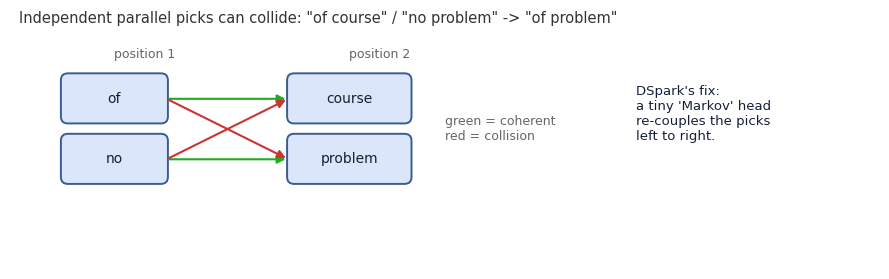

In [13]:
fig, ax = plt.subplots(figsize=(9, 2.9)); blank(ax, (0, 10), (0, 3))
ax.text(0.1, 2.85, 'Independent parallel picks can collide: "of course" / "no problem" -> "of problem"',
        fontsize=10.5, color="#333")
box(ax, 0.6, 1.7, 1.2, 0.55, "of", fc=BLUE); box(ax, 0.6, 1.0, 1.2, 0.55, "no", fc=BLUE)
box(ax, 3.2, 1.7, 1.4, 0.55, "course", fc=BLUE); box(ax, 3.2, 1.0, 1.4, 0.55, "problem", fc=BLUE)
ax.text(1.2, 2.45, "position 1", fontsize=9, color="#666"); ax.text(3.9, 2.45, "position 2", fontsize=9, color="#666")
arrow(ax, 1.8, 1.97, 3.2, 1.97, color="#2a2"); arrow(ax, 1.8, 1.27, 3.2, 1.27, color="#2a2")
arrow(ax, 1.8, 1.97, 3.2, 1.27, color="#c33", style="-|>"); arrow(ax, 1.8, 1.27, 3.2, 1.97, color="#c33")
ax.text(5.0, 1.5, "green = coherent\nred = collision", fontsize=9, color="#666")
ax.text(7.2, 1.5, "DSpark's fix:\na tiny 'Markov' head\nre-couples the picks\nleft to right.", fontsize=9.5, color="#14203a")
plt.tight_layout(); plt.savefig("assets/fig_collision.png", dpi=110); plt.show()

### DSpark's design

DSpark keeps the heavy work parallel but adds a cheap sequential correction:

1. a **parallel backbone** that drafts the whole block in one pass — it doesn't start from scratch, it
   *reuses the target's own hidden states* as context (an idea from EAGLE/DFlash);
2. a tiny **Markov head** that nudges each position based on the token actually chosen just before it,
   restoring the coupling that pure parallel drafting loses.

> **How this differs from Multi-Token Prediction (MTP).** MTP also predicts several future tokens, but
> places the work differently. In DeepSeek-V3 (DeepSeek-AI, [2024](https://arxiv.org/abs/2412.19437))
> MTP is *built into the target* — extra modules, trained jointly, that predict tokens **sequentially**
> (each conditions on the previous prediction), so $k$ tokens cost $k$ heavy passes; the drafter DSpark
> is benchmarked against, "MTP-1", is a single such module. The parallel-heads variant (Gloeckle et
> al., [2024](https://arxiv.org/abs/2404.19737); Medusa, Cai et al.,
> [2024](https://arxiv.org/abs/2401.10774)) is the opposite — independent heads with **no** cross-token
> dependency, i.e. the collision above. DSpark is a *separate* draft distilled from a frozen target
> that keeps the parallel speed (one block-sized pass) and restores the dependency with the cheap
> Markov head instead of more heavy passes.

The picture below is the whole draft. Notice how **little** goes in: a single **anchor** token (the
last committed token) followed by $\gamma-1$ **mask** placeholders, one per block position. The draft
never re-reads the prompt as tokens — the entire history reaches it through the **injected target
hidden states**. Concretely, we grab the target's hidden states from a few of its layers
($l_1,\dots,l_m$), concatenate and project them ($W_c$ then RMSNorm) into one context tensor
$H_{\text{ctx}}$, and hand $H_{\text{ctx}}$ to *every* draft layer as extra **keys and values** the
block attends to — cross-attention onto the target's own memory. Those hidden states cover the tokens
the target has already run a forward over (the prompt plus everything verified so far) but *not* the
current anchor: the anchor was just *predicted*, so the target hasn't computed a hidden state for it
yet (that happens at the next verification, which then appends it to $H_{\text{ctx}}$). That asymmetry
is exactly why the anchor also enters as an input **token** — its embedding carries the just-committed
token into the block, while everything older arrives through $H_{\text{ctx}}$. So one anchor is enough.
A single parallel pass turns anchor+masks into per-position
hidden states $h_k$, and the (frozen) LM head maps those to base scores $U_k$. Two small heads then
read off the $h_k$: the **Markov head** (next) adds a previous-token bias to $U_k$, and a **confidence
head** — which we build in §5 — scores how likely each drafted token is to survive verification.

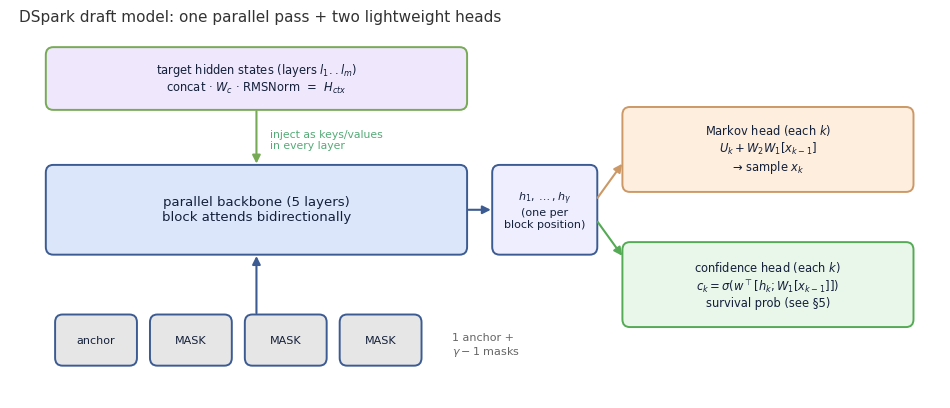

In [14]:
fig, ax = plt.subplots(figsize=(9.6, 4.2)); blank(ax, (0, 10), (0, 4))
ax.text(0.1, 3.9, "DSpark draft model: one parallel pass + two lightweight heads", fontsize=11, color="#333")
box(ax, 0.4, 3.0, 4.5, 0.62,
    "target hidden states (layers $l_1..l_m$)\nconcat · $W_c$ · RMSNorm  =  $H_{ctx}$",
    fc="#efe7fb", ec="#7a5", fs=8.3)
box(ax, 0.4, 1.5, 4.5, 0.9, "parallel backbone (5 layers)\nblock attends bidirectionally", fc=BLUE, fs=9.5)
arrow(ax, 2.65, 3.0, 2.65, 2.4, color="#7a5")
ax.text(2.8, 2.58, "inject as keys/values\nin every layer", fontsize=7.8, color="#5a7")
for i, t in enumerate(["anchor", "MASK", "MASK", "MASK"]):
    box(ax, 0.5 + i * 1.02, 0.35, 0.85, 0.5, t, fc=GREY, fs=8)
arrow(ax, 2.65, 0.85, 2.65, 1.5)
ax.text(4.75, 0.45, "1 anchor +\n$\\gamma-1$ masks", fontsize=8, color="#666")
box(ax, 5.2, 1.5, 1.1, 0.9, "$h_1,\\dots,h_\\gamma$\n(one per\nblock position)", fc="#eef", fs=8)
arrow(ax, 4.9, 1.95, 5.2, 1.95)
box(ax, 6.6, 2.15, 3.1, 0.85, "Markov head (each $k$)\n$U_k + W_2 W_1[x_{k-1}]$\n→ sample $x_k$",
    fc="#fdeede", ec="#c96", fs=8.3)
arrow(ax, 6.3, 2.05, 6.6, 2.45, color="#c96")
box(ax, 6.6, 0.75, 3.1, 0.85, "confidence head (each $k$)\n$c_k=\\sigma(w^\\top[h_k; W_1[x_{k-1}]])$\nsurvival prob (see §5)",
    fc="#e9f6ea", ec="#5a5", fs=8.3)
arrow(ax, 6.3, 1.85, 6.6, 1.45, color="#5a5")
plt.tight_layout(); plt.savefig("assets/fig_architecture.png", dpi=110); plt.show()

That single "inject as keys/values" arrow hides the actual attention, so we zoom into one draft
layer. The **queries come only from the $\gamma$ block positions** (the anchor and the masks); the
**keys and values** are the *concatenation* of the injected context $H_{\text{ctx}}$ and the block
itself. So $H_{\text{ctx}}$ is *read but never queried* — a cross-attention-style prefix that the
block attends into but that is never re-computed (those vectors stay exactly as the target produced
them, and the layer emits one output per block position). Crucially there is **no causal mask inside
the block** — every draft position sees all of the context *and* all of the other block positions at
once (that bidirectional view is what lets one parallel pass fill every slot):

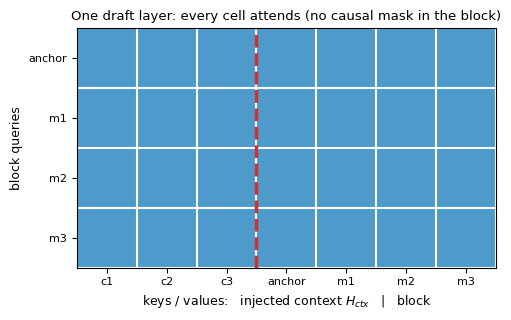

In [15]:
fig, ax = plt.subplots(figsize=(7.6, 3.3))
nctx, nblk = 3, 4
ax.imshow(np.ones((nblk, nctx + nblk)), cmap="Blues", vmin=0, vmax=1.7, aspect="equal")
ax.set_xticks(range(nctx + nblk)); ax.set_xticklabels(["c1", "c2", "c3", "anchor", "m1", "m2", "m3"], fontsize=8)
ax.set_yticks(range(nblk)); ax.set_yticklabels(["anchor", "m1", "m2", "m3"], fontsize=8)
ax.axvline(nctx - 0.5, color="#c33", lw=2.5, ls="--")            # context | block divider
ax.set_xticks(np.arange(-.5, nctx + nblk, 1), minor=True)
ax.set_yticks(np.arange(-.5, nblk, 1), minor=True)
ax.grid(which="minor", color="white", lw=1.5); ax.tick_params(which="minor", length=0)
ax.set_xlabel("keys / values:   injected context $H_{ctx}$   |   block", fontsize=9)
ax.set_ylabel("block queries", fontsize=9)
ax.set_title("One draft layer: every cell attends (no causal mask in the block)", fontsize=9.5)
plt.tight_layout(); plt.savefig("assets/fig_attention.png", dpi=110); plt.show()

### The Markov head, precisely

For each block position $k$, the backbone produces base scores $U_k$ over the vocabulary. The Markov
head adds a **bias that depends only on the previous token** $x_{k-1}$ — a learned bigram effect.
Writing it as a full $V\times V$ table would be huge, so DSpark factors it through a small rank
$r=256$:

$$ B(x_{k-1},\cdot) = W_1[x_{k-1}]\,W_2, \qquad
   p_k(\cdot \mid x_{<k}) = \mathrm{softmax}\big(U_k + B(x_{k-1},\cdot)\big). $$

So the backbone runs **once** in parallel to produce all the base scores $U_1,\dots,U_\gamma$ at once,
then we walk the block left-to-right: at each step we add the previous token's bias and pick $x_k$.
Each correction step is just an embedding lookup ($W_1$) and one small matmul ($W_2$) — heavy work
parallel, correction nearly free. That is what *semi-autoregressive* means, and the picture below
makes the two timescales explicit.

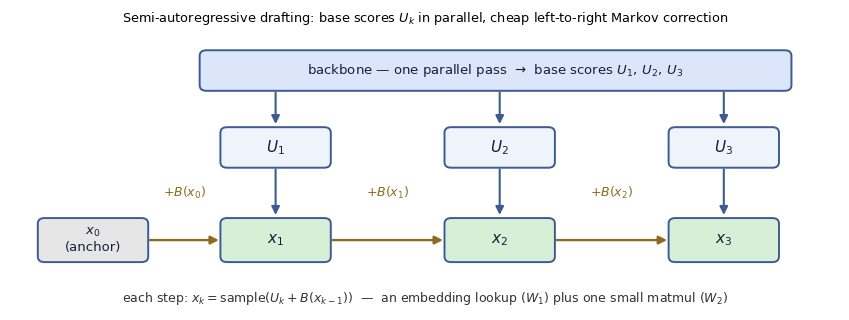

In [16]:
fig, ax = plt.subplots(figsize=(8.6, 3.3)); blank(ax, (0, 10), (0, 4))
box(ax, 2.3, 3.15, 7.1, 0.55, "backbone — one parallel pass  \u2192  base scores $U_1,\\,U_2,\\,U_3$", fc=BLUE, fs=9.5)
for cx, lab in [(3.2, "$U_1$"), (5.9, "$U_2$"), (8.6, "$U_3$")]:
    box(ax, cx - 0.65, 2.05, 1.3, 0.55, lab, fc="#eef3fc", fs=11)
    arrow(ax, cx, 3.15, cx, 2.62)
    arrow(ax, cx, 2.05, cx, 1.32)
box(ax, 0.35, 0.7, 1.3, 0.6, "$x_0$\n(anchor)", fc=GREY, fs=9.5)
for cx, lab in [(3.2, "$x_1$"), (5.9, "$x_2$"), (8.6, "$x_3$")]:
    box(ax, cx - 0.65, 0.7, 1.3, 0.6, lab, fc=GREEN, fs=11)
for x0c, x1c, blab in [(1.0, 3.2, "$+B(x_0)$"), (3.2, 5.9, "$+B(x_1)$"), (5.9, 8.6, "$+B(x_2)$")]:
    arrow(ax, x0c + 0.65, 1.0, x1c - 0.65, 1.0, color="#8a6d1f", lw=1.7)
    ax.text((x0c + x1c) / 2, 1.62, blab, ha="center", fontsize=9, color="#8a6d1f")
ax.set_title("Semi-autoregressive drafting: base scores $U_k$ in parallel, cheap left-to-right Markov correction",
             fontsize=9.3)
ax.text(5.0, 0.12,
        r"each step: $x_k=\mathrm{sample}(U_k+B(x_{k-1}))$  —  an embedding lookup ($W_1$) plus one small matmul ($W_2$)",
        ha="center", fontsize=9, color="#333")
plt.tight_layout(); plt.savefig("assets/fig_markov_chain.png", dpi=110); plt.show()

The top row is produced in a single shot; only the bottom chain is sequential, and each link is
tiny. Now we write the model. We build it in three small pieces: one attention layer, one
transformer block, then the full draft.

In [17]:
def apply_rotary(q, k, cos, sin):
    # rotary position embedding; q covers only the block (the tail), k covers context + block
    cos, sin = cos.unsqueeze(1), sin.unsqueeze(1)
    ql = q.size(-2)
    q = (q * cos[..., -ql:, :]) + (rotate_half(q) * sin[..., -ql:, :])
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

class DSparkAttention(nn.Module):
    # block positions attend to [injected target features ; the block itself] with no causal mask
    def __init__(self, cfg):
        super().__init__()
        self.hd = cfg.head_dim
        self.nh, self.nkv = cfg.num_attention_heads, cfg.num_key_value_heads
        self.groups, self.scale = self.nh // self.nkv, self.hd ** -0.5
        self.q_proj = nn.Linear(cfg.hidden_size, self.nh * self.hd, bias=False)
        self.k_proj = nn.Linear(cfg.hidden_size, self.nkv * self.hd, bias=False)
        self.v_proj = nn.Linear(cfg.hidden_size, self.nkv * self.hd, bias=False)
        self.o_proj = nn.Linear(self.nh * self.hd, cfg.hidden_size, bias=False)
        self.q_norm = Qwen3RMSNorm(self.hd, eps=cfg.rms_norm_eps)
        self.k_norm = Qwen3RMSNorm(self.hd, eps=cfg.rms_norm_eps)

    def forward(self, block, ctx_kv, cos, sin):
        B, T = block.shape[:2]; C = ctx_kv.shape[1]
        q = self.q_norm(self.q_proj(block).view(B, T, self.nh, self.hd)).transpose(1, 2)
        k = torch.cat([self.k_proj(ctx_kv), self.k_proj(block)], 1).view(B, C + T, self.nkv, self.hd)
        v = torch.cat([self.v_proj(ctx_kv), self.v_proj(block)], 1).view(B, C + T, self.nkv, self.hd)
        k = self.k_norm(k).transpose(1, 2); v = v.transpose(1, 2)
        q, k = apply_rotary(q, k, cos, sin)
        k = k.repeat_interleave(self.groups, 1); v = v.repeat_interleave(self.groups, 1)
        o = F.scaled_dot_product_attention(q, k, v, scale=self.scale)
        return self.o_proj(o.transpose(1, 2).reshape(B, T, -1))

class DSparkLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.self_attn = DSparkAttention(cfg)
        self.mlp = Qwen3MLP(cfg)
        self.input_layernorm = Qwen3RMSNorm(cfg.hidden_size, eps=cfg.rms_norm_eps)
        self.post_attention_layernorm = Qwen3RMSNorm(cfg.hidden_size, eps=cfg.rms_norm_eps)

    def forward(self, block, ctx_kv, cos, sin):
        block = block + self.self_attn(self.input_layernorm(block), ctx_kv, cos, sin)
        block = block + self.mlp(self.post_attention_layernorm(block))
        return block

The full draft ties it together: it embeds the `[anchor, MASK, ...]` input, runs the layers with the
injected target features as extra keys/values, and exposes the language-model head plus the two tiny
heads (Markov and confidence). `draft_block` is the sequential stage — it samples the
block left-to-right, adding the Markov bias at each step.

In [18]:
class DSparkDraft(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.block_size = cfg.block_size
        self.mask_token_id = cfg.mask_token_id
        self.target_layer_ids = list(cfg.target_layer_ids)     # which target layers we reuse
        H, V, m = cfg.hidden_size, cfg.vocab_size, len(self.target_layer_ids)
        self.embed_tokens = nn.Embedding(V, H)
        self.layers = nn.ModuleList(DSparkLayer(cfg) for _ in range(cfg.num_hidden_layers))
        self.norm = Qwen3RMSNorm(H, eps=cfg.rms_norm_eps)
        self.rotary_emb = Qwen3RotaryEmbedding(cfg)
        self.fc = nn.Linear(m * H, H, bias=False)              # fuse the m reused layers -> draft width
        self.hidden_norm = Qwen3RMSNorm(H, eps=cfg.rms_norm_eps)
        self.lm_head = nn.Linear(H, V, bias=False)
        self.markov_w1 = nn.Embedding(V, cfg.markov_rank)      # low-rank bigram bias: W1[x] then W2
        self.markov_w2 = nn.Linear(cfg.markov_rank, V, bias=False)
        self.confidence_proj = nn.Linear(H + cfg.markov_rank, 1)

    def backbone(self, ctx_features, anchor_id, ctx_len):
        # one parallel pass over [anchor, MASK x (block-1)] -> hidden states for the block
        B = ctx_features.shape[0]
        block_ids = torch.full((B, self.block_size), self.mask_token_id,
                               device=ctx_features.device, dtype=torch.long)
        block_ids[:, 0] = anchor_id
        block = self.embed_tokens(block_ids)
        pos = torch.arange(ctx_len + self.block_size, device=ctx_features.device)[None]
        cos, sin = self.rotary_emb(block, pos)
        ctx_kv = self.hidden_norm(self.fc(ctx_features))       # projected, normed target context
        for layer in self.layers:
            block = layer(block, ctx_kv, cos, sin)
        return self.norm(block)

    def markov_bias(self, prev_token_ids):
        return self.markov_w2(self.markov_w1(prev_token_ids))

    def draft_block(self, block_hidden, anchor_id, temperature=0.0, use_markov=True):
        base = self.lm_head(block_hidden)                      # [B, T, V] base scores in one shot
        sampled, probs, prev = [], [], anchor_id
        for k in range(base.shape[1]):                         # sample left-to-right (cheap)
            logits = base[:, k, :] + (self.markov_bias(prev) if use_markov else 0.0)
            p = to_probs(logits, temperature)
            nxt = p.argmax(-1) if temperature < 1e-5 else torch.multinomial(p, 1).squeeze(-1)
            sampled.append(nxt); probs.append(p); prev = nxt
        return torch.stack(sampled, 1), torch.stack(probs, 1)

    def confidence(self, block_hidden, prev_token_ids):
        feats = torch.cat([block_hidden, self.markov_w1(prev_token_ids)], dim=-1)
        return torch.sigmoid(self.confidence_proj(feats).squeeze(-1).float())

def extract_features(hidden_states, layer_ids):
    # concatenate the target's hidden states from the chosen layers (index+1: 0 is the embedding)
    return torch.cat([hidden_states[l + 1] for l in layer_ids], dim=-1)

There is no separate sampling stage after the Markov head — the
head *is* the sampling. Forming $p_k=\mathrm{softmax}(U_k+B(x_{k-1}))$ and drawing $x_k$ happen in the
*same* left-to-right loop, so the instant that loop finishes the block is **fully drafted**: nothing
is left to sample. (Only the base scores $U_k$ came from the parallel backbone; the Markov correction
and the draw are the sequential part — that split is the whole point of *semi-autoregressive*.)

`draft_block` therefore returns *two* things: the $\gamma$ proposed tokens (`sampled`) that we hand to
the target, and the full per-position distributions (`probs`, the $p^d_k$). We keep the distributions
because the lossless verifier from §2 needs $p^d_k$ to compute the accept ratio
$\min(1,\,p^t_k/p^d_k)$. What comes next is *not* more drafting — the target scores all $\gamma$
proposals in one pass and the verifier keeps the longest correct prefix.

Because we rebuilt it faithfully, we can load **DeepSeek's released weights** straight into
our modules. If every parameter finds a home (`missing` and `unexpected` both empty), our code matches
their checkpoint exactly.

In [19]:
DRAFT_NAME = "deepseek-ai/dspark_qwen3_4b_block7"
draft_cfg = AutoConfig.from_pretrained(DRAFT_NAME)
draft = DSparkDraft(draft_cfg).to(DEVICE, DTYPE).eval()

state = load_file(hf_hub_download(DRAFT_NAME, "model.safetensors"))
remap = {}
for key, val in state.items():                                  # their names -> our attribute names
    remap[(key.replace("markov_head.markov_w1", "markov_w1")
              .replace("markov_head.markov_w2", "markov_w2")
              .replace("confidence_head.proj", "confidence_proj"))] = val
missing, unexpected = draft.load_state_dict(remap, strict=False)
print("missing:", missing, "| unexpected:", unexpected)
print(f"draft: {draft_cfg.num_hidden_layers} layers | block_size {draft.block_size} "
      f"| reuses target layers {draft.target_layer_ids} | {gpu_mem()}")

missing: [] | unexpected: []
draft: 5 layers | block_size 7 | reuses target layers [1, 9, 17, 25, 33] | 10.9 GB in use


To see whether the Markov head earns its keep, we draft one block with it **off** (pure parallel) and **on**,
from the same backbone output. Off, the tail often derails into repetition or a collision; on, the
tokens snap into a coherent phrase.

In [20]:
@torch.inference_mode()
def first_block(prompt):
    pids = chat_ids(prompt)
    out = target(input_ids=pids, position_ids=torch.arange(pids.shape[1], device=DEVICE)[None],
                 past_key_values=DynamicCache(), use_cache=True, output_hidden_states=True)
    anchor = out.logits[:, -1].argmax(-1)
    ctx = extract_features(out.hidden_states, draft.target_layer_ids)
    bh = draft.backbone(ctx, anchor, ctx_len=pids.shape[1])
    off, _ = draft.draft_block(bh, anchor, use_markov=False)
    on, _ = draft.draft_block(bh, anchor, use_markov=True)
    show = lambda t: repr(tok.decode([int(anchor)] + t[0].tolist()))
    print("Markov OFF (pure parallel):", show(off))
    print("Markov ON  (coupled)      :", show(on))

first_block("List three primary colors.")
first_block("The capital of France is")

Markov OFF (pure parallel): 'The primary primary are are,red**,'
Markov ON  (coupled)      : 'The primary colors are **red, red'


Markov OFF (pure parallel): 'The capital of of is Paris****'
Markov ON  (coupled)      : 'The capital of France is **Paris**'


## 5. DSpark, part 2 — knowing when to stop

The Markov head makes the draft better, but acceptance still fades toward the end of a block. The
**confidence head** turns that into a lever: it predicts, per position, the probability that the token
*survives* verification, so we can **truncate the block before the target ever sees it** — never
spending verification on tail tokens that were going to be rejected anyway.

$$ c_k = \sigma\big(w^\top[\,h_k\,;\,W_1[x_{k-1}]\,]\big). $$

Its training target is exact: the true per-step acceptance probability equals
$1 - \tfrac12\lVert p^d - p^t\rVert_1$. Because a prefix survives only if *every* token in it does, the
running product $\prod_{i\le k} c_i$ estimates the accepted-run length. The simplest policy is a
threshold: cut the block at the first position whose confidence falls below it.

The saving is only in the *target's* verification cost (the draft
already produced the whole block), and — in the paper's words — that cost *"depends strictly on the
engine load"*:

- **Under light load** (batch 1, what we measure here) an extra verification is nearly free: the
  target pass is memory-bound, so streaming its weights dominates and checking 7 tokens costs about
  the same as checking 1. Pruning saves little wall-clock and can even lower $\tau$, so on a single
  stream you usually leave the block un-pruned.
- **Under high concurrency** the pass is compute-bound, and every unnecessary verification *"occupies
  target model batch capacity that could otherwise serve other active requests."* There, cutting the
  doomed tail reclaims capacity and lifts aggregate throughput.

So the confidence head is a **throughput lever for loaded servers, not a batch-1 speedup** — the
"verify smarter" term in $L=(T_\text{draft}+T_\text{verify})/\tau$. In production, DSpark goes
further: its verification length is set not by a fixed cutoff but by a **hardware-aware scheduler**
that reads real-time load (the "scheduled" in *Confidence-Scheduled*). The single threshold we use
below is a didactic stand-in for it. We put a number on the saving in §7. First, look
at the confidences on a real block — note how they decay, which is what makes the *tail* the right
thing to cut:

drafted: [' sky', ' is', ' blue', ' because', ' of', ' a', ' shorter']
confidence c_k        : [1.    0.998 1.    0.928 0.775 0.585 0.406]
prefix survival prod  : [1.    0.998 0.998 0.927 0.718 0.42  0.171]


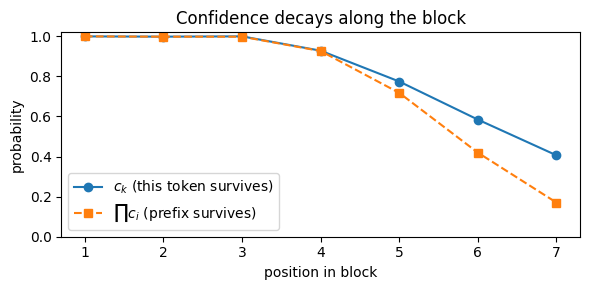

In [21]:
@torch.inference_mode()
def show_confidence(prompt):
    pids = chat_ids(prompt)
    out = target(input_ids=pids, position_ids=torch.arange(pids.shape[1], device=DEVICE)[None],
                 past_key_values=DynamicCache(), use_cache=True, output_hidden_states=True)
    anchor = out.logits[:, -1].argmax(-1)
    ctx = extract_features(out.hidden_states, draft.target_layer_ids)
    bh = draft.backbone(ctx, anchor, ctx_len=pids.shape[1])
    tokens, _ = draft.draft_block(bh, anchor, use_markov=True)
    prev = torch.cat([anchor[:, None], tokens[:, :-1]], 1)
    c = draft.confidence(bh, prev)[0].float().cpu().numpy()
    return tokens[0], c

tokens, c = show_confidence("Explain in one sentence why the sky is blue.")
print("drafted:", [tok.decode([int(t)]) for t in tokens])
print("confidence c_k        :", np.round(c, 3))
print("prefix survival prod  :", np.round(np.cumprod(c), 3))
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(c) + 1), c, "o-", label="$c_k$ (this token survives)")
plt.plot(range(1, len(c) + 1), np.cumprod(c), "s--", label=r"$\prod c_i$ (prefix survives)")
plt.xlabel("position in block"); plt.ylabel("probability"); plt.ylim(0, 1.02)
plt.legend(); plt.title("Confidence decays along the block")
plt.tight_layout(); plt.savefig("assets/confidence.png", dpi=110); plt.show()

## 6. The full DSpark loop

Now assemble one cycle end to end. The picture first, then the code:

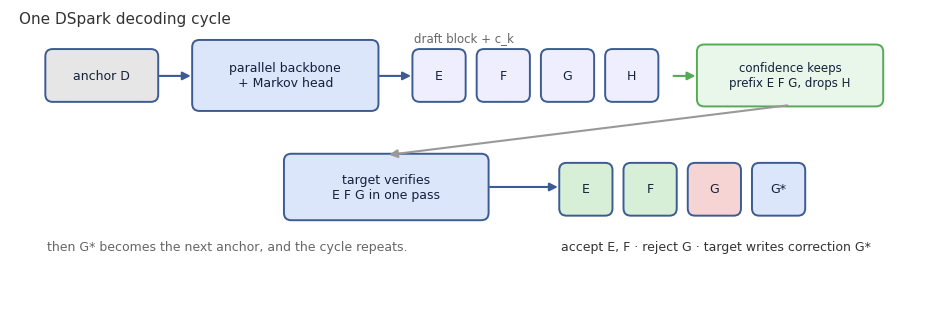

In [22]:
fig, ax = plt.subplots(figsize=(9.6, 3.4)); blank(ax, (0, 10), (0, 3.4))
ax.text(0.1, 3.25, "One DSpark decoding cycle", fontsize=11, color="#333")
box(ax, 0.4, 2.4, 1.2, 0.55, "anchor D", fc=GREY, fs=9)
box(ax, 2.0, 2.3, 2.0, 0.75, "parallel backbone\n+ Markov head", fc=BLUE, fs=9)
arrow(ax, 1.6, 2.67, 2.0, 2.67)
for i, t in enumerate(["E", "F", "G", "H"]):
    box(ax, 4.4 + i * 0.7, 2.4, 0.55, 0.55, t, fc="#eef", fs=9)
arrow(ax, 4.0, 2.67, 4.4, 2.67)
ax.text(4.4, 3.05, "draft block + c_k", fontsize=8.5, color="#666")
box(ax, 7.5, 2.35, 2.0, 0.65, "confidence keeps\nprefix E F G, drops H", fc="#e9f6ea", ec="#5a5", fs=8.5)
arrow(ax, 7.2, 2.67, 7.5, 2.67, color="#5a5")
box(ax, 3.0, 1.1, 2.2, 0.7, "target verifies\nE F G in one pass", fc="#dbe6fb", fs=9)
arrow(ax, 8.5, 2.35, 4.1, 1.8, color="#999")
for i, (t, c) in enumerate([("E", GREEN), ("F", GREEN), ("G", RED), ("G*", BLUE)]):
    box(ax, 6.0 + i * 0.7, 1.15, 0.55, 0.55, t, fc=c, fs=9)
arrow(ax, 5.2, 1.45, 6.0, 1.45)
ax.text(6.0, 0.75, "accept E, F · reject G · target writes correction G*", fontsize=9, color="#333")
ax.text(0.4, 0.75, "then G* becomes the next anchor, and the cycle repeats.", fontsize=9, color="#666")
plt.tight_layout(); plt.savefig("assets/fig_dspark_cycle.png", dpi=110); plt.show()

In code: the target's hidden states seed the draft's context; the backbone + Markov head propose a
block; the confidence head optionally trims the tail; the target verifies with our `verify` from §2;
we commit the accepted run plus the bonus/correction, and recycle the freshly verified hidden states
as context for the next round.

In [23]:
def _accept_record(block_size):
    return {"acc": np.zeros(block_size), "tot": np.zeros(block_size)}

def _record(rec, gamma, n_acc):
    for k in range(min(n_acc + 1, gamma)):            # positions actually reached this cycle
        rec["tot"][k] += 1
        if k < n_acc:
            rec["acc"][k] += 1

@torch.inference_mode()
def spec_decode_dspark(target, draft, input_ids, temperature=0.0, max_new=MAX_NEW,
                       conf_threshold=0.0, use_markov=True, rec=None, _timing=None):
    if _timing is not None:
        torch.cuda.synchronize(); _t0 = time.time()
    cache = DynamicCache()
    n_in = input_ids.shape[1]
    out = target(input_ids=input_ids, position_ids=torch.arange(n_in, device=DEVICE)[None],
                 past_key_values=cache, use_cache=True, output_hidden_states=True)
    anchor = out.logits[:, -1].argmax(-1, keepdim=True)
    ctx = extract_features(out.hidden_states, draft.target_layer_ids)     # draft context = prompt feats
    committed, accept_lens, prop_lens, start = [int(anchor)], [], [], n_in
    if _timing is not None:
        torch.cuda.synchronize(); _timing["prefill_s"] = time.time() - _t0; _t1 = time.time()
    while len(committed) < max_new:
        bh = draft.backbone(ctx, anchor.squeeze(1), ctx_len=ctx.shape[1])
        tokens, dprobs = draft.draft_block(bh, anchor.squeeze(1), temperature, use_markov)
        gamma = draft.block_size
        if conf_threshold > 0:                                            # confidence-based pruning
            prev = torch.cat([anchor, tokens[:, :-1]], 1)
            conf = draft.confidence(bh, prev)[0]
            below = (conf < conf_threshold).nonzero()
            if below.numel() > 0:
                gamma = max(1, int(below[0]))
        prop_lens.append(gamma)
        verify_ids = torch.cat([anchor, tokens[:, :gamma]], 1)
        vout = target(input_ids=verify_ids,
                      position_ids=torch.arange(start, start + gamma + 1, device=DEVICE)[None],
                      past_key_values=cache, use_cache=True, output_hidden_states=True)
        tp = to_probs(vout.logits[0], temperature)
        n_acc, bonus = verify(tp, tokens[0, :gamma], dprobs[0, :gamma])
        if rec is not None:
            _record(rec, gamma, n_acc)
        committed += [int(t) for t in tokens[0, :n_acc]] + [bonus]
        accept_lens.append(n_acc + 1); start += n_acc + 1
        cache.crop(start)
        ctx = torch.cat([ctx, extract_features(vout.hidden_states, draft.target_layer_ids)[:, :n_acc + 1]], 1)
        anchor = torch.tensor([[bonus]], device=DEVICE)
        if bonus in STOP:
            break
    if _timing is not None:
        torch.cuda.synchronize()
        _timing["decode_s"] = time.time() - _t1; _timing["decoded"] = len(committed) - 1
    return committed, {"accept_lens": accept_lens, "prop_lens": prop_lens}

ds_toks, ds_stats = spec_decode_dspark(target, draft, ids)
print(f"DSpark: tau = {np.mean(ds_stats['accept_lens']):.2f} tokens / target pass "
      f"over {len(ds_stats['accept_lens'])} cycles | {gpu_mem()}")
print(tok.decode(ds_toks))

DSpark: tau = 3.14 tokens / target pass over 21 cycles | 10.9 GB in use
The sky appears blue because molecules in the Earth's atmosphere scatter shorter wavelengths of light, like blue, more efficiently than longer wavelengths, such as red. When sunlight enters the atmosphere, these blue light waves are scattered in all directions by gas molecules and small particles, making the sky look blue to observers on the ground.<|im_end|><|im_end|>
<|endoftext|>


### Is it really lossless?

The promise was *identical* output. At temperature 0, DSpark must reproduce plain greedy decoding
token-for-token. In 16-bit they can split at a rare near-tie: verifying a block in one pass vs. one
token at a time nudges the scores by ~1e-3, occasionally flipping an `argmax` between two nearly-equal
options. That is rounding, not a modeling error — in exact arithmetic the rule is provably exact.

In [24]:
def matched_prefix(a, b):
    n = min(len(a), len(b))
    for i in range(n):
        if a[i] != b[i]:
            return i
    return n

ar_g = greedy_ar(target, ids)
ds_g, _ = spec_decode_dspark(target, draft, ids)
print(f"{str(DTYPE).split('.')[-1]}: greedy and DSpark agree on {matched_prefix(ar_g, ds_g)}"
      f"/{min(len(ar_g), len(ds_g))} tokens")

# On a big GPU we can afford float32 copies and show the match is then EXACT. A T4 can't hold
# fp32 of a 4B model, so we skip it there (the 16-bit near-match above already makes the point).
big = DTYPE == torch.bfloat16 and \
      torch.cuda.get_device_properties(0).total_memory / 1e9 > 40
if big:
    target.float(); draft.float()
    a32, (d32, _) = greedy_ar(target, ids), spec_decode_dspark(target, draft, ids)
    print(f"float32: agree on {matched_prefix(a32, d32)}/{min(len(a32), len(d32))}  <- exact = lossless")
    target.to(DTYPE); draft.to(DTYPE)
    torch.cuda.reset_peak_memory_stats()    # the fp32 copies were transient; don't count them
else:
    print("float32 exact-match demo skipped (needs a >40 GB GPU); the 16-bit match above is the point.")

bfloat16: greedy and DSpark agree on 64/64 tokens


float32: agree on 64/64  <- exact = lossless


## 7. Does it pay off?

Three measurements, all at temperature 0. We reuse the AR-draft baseline numbers from §3 (that model
is freed now) and measure DSpark live.

In [25]:
# --- 7.1 acceptance length by domain: AR-draft (from sec 3) vs DSpark ---
dspark_tau = {}
for name, pid in PROMPT_IDS.items():
    _, st = spec_decode_dspark(target, draft, pid)
    dspark_tau[name] = float(np.mean(st["accept_lens"]))
for name in PROMPTS:
    print(f"{name:5s} | AR-draft tau {BASE['AR-draft tau'][name]:.2f} | DSpark tau {dspark_tau[name]:.2f}")
print(f"mean  | AR-draft tau {np.mean(list(BASE['AR-draft tau'].values())):.2f} "
      f"| DSpark tau {np.mean(list(dspark_tau.values())):.2f}")

math  | AR-draft tau 2.30 | DSpark tau 3.25
code  | AR-draft tau 3.06 | DSpark tau 6.40
chat  | AR-draft tau 2.40 | DSpark tau 3.96
mean  | AR-draft tau 2.59 | DSpark tau 4.54


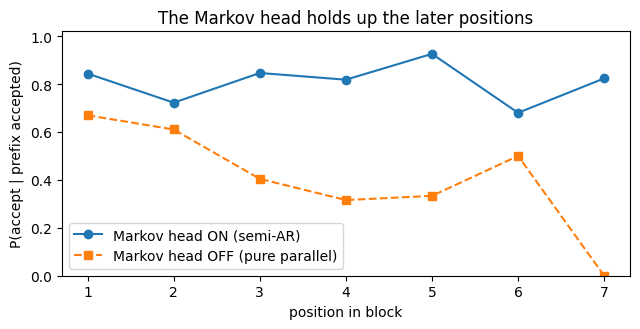

mean accept rate  ON: 0.809 | OFF: 0.405


In [26]:
# --- 7.2 per-position accept rate: Markov head ON vs OFF ---
rec_on, rec_off = _accept_record(draft.block_size), _accept_record(draft.block_size)
for pid in PROMPT_IDS.values():
    spec_decode_dspark(target, draft, pid, use_markov=True, rec=rec_on)
    spec_decode_dspark(target, draft, pid, use_markov=False, rec=rec_off)
acc_on = rec_on["acc"] / np.maximum(rec_on["tot"], 1)
acc_off = rec_off["acc"] / np.maximum(rec_off["tot"], 1)
plt.figure(figsize=(6.5, 3.4))
plt.plot(range(1, draft.block_size + 1), acc_on, "o-", label="Markov head ON (semi-AR)")
plt.plot(range(1, draft.block_size + 1), acc_off, "s--", label="Markov head OFF (pure parallel)")
plt.xlabel("position in block"); plt.ylabel("P(accept | prefix accepted)"); plt.ylim(0, 1.02)
plt.legend(); plt.title("The Markov head holds up the later positions")
plt.tight_layout(); plt.savefig("assets/accept_by_position.png", dpi=110); plt.show()
print("mean accept rate  ON:", round(float(acc_on.mean()), 3), "| OFF:", round(float(acc_off.mean()), 3))

plain decoding       15.3 tok/s  (1.00x)
AR-draft spec        13.1 tok/s  (0.85x)
DSpark               56.1 tok/s  (3.66x)


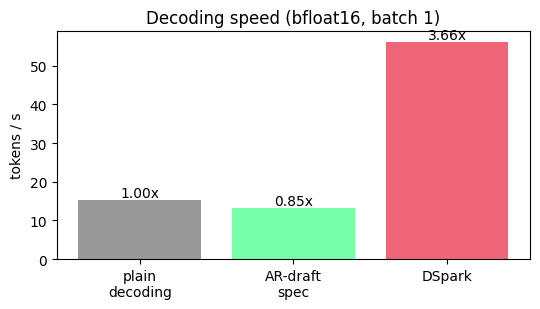

In [27]:
# --- 7.3 decode speed (prefill excluded): plain vs AR-draft (sec 3) vs DSpark ---
tm = {}
spec_decode_dspark(target, draft, ids, _timing=tm)
ds_tps = tm["decoded"] / tm["decode_s"]
speeds = {"plain\ndecoding": BASE["AR tok/s"], "AR-draft\nspec": BASE["AR-draft tok/s"], "DSpark": ds_tps}
base = speeds["plain\ndecoding"]
for k, v in speeds.items():
    print(f"{k.replace(chr(10),' '):18s} {v:6.1f} tok/s  ({v/base:.2f}x)")
plt.figure(figsize=(5.5, 3.2))
names = list(speeds); vals = [speeds[k] for k in names]
plt.bar(names, vals, color=["#999", "#7fa", "#e67"])
for i, v in enumerate(vals):
    plt.text(i, v, f"{v/base:.2f}x", ha="center", va="bottom")
plt.ylabel("tokens / s"); plt.title(f"Decoding speed ({str(DTYPE).split('.')[-1]}, batch 1)")
plt.tight_layout(); plt.savefig("assets/speedup.png", dpi=110); plt.show()

threshold 0.0 | proposed 7.00 | accepted tau 4.27 | target positions / committed token 1.88


threshold 0.5 | proposed 5.92 | accepted tau 4.27 | target positions / committed token 1.62


threshold 0.7 | proposed 4.48 | accepted tau 4.11 | target positions / committed token 1.34


threshold 0.9 | proposed 2.67 | accepted tau 3.31 | target positions / committed token 1.11


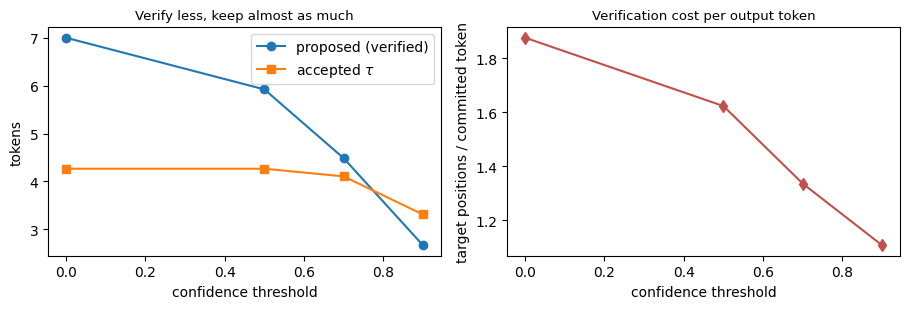

In [28]:
# --- 7.4 the confidence knob: prune the block BEFORE verifying, trade length for survival ---
# Cost model: the target verifies (1 anchor + gamma draft) positions per cycle and we commit tau of
# them, so "target positions / committed token" = (gamma + 1) / tau is the verification work per unit
# of output -- the quantity a busy, compute-bound server pays. Lower is cheaper.
sweep = [0.0, 0.5, 0.7, 0.9]
prop_s, tau_s, cost_s = [], [], []
for th in sweep:
    pl, al = [], []
    for pid in PROMPT_IDS.values():
        _, st = spec_decode_dspark(target, draft, pid, conf_threshold=th)
        pl += st["prop_lens"]; al += st["accept_lens"]
    mp, mt = np.mean(pl), np.mean(al)
    prop_s.append(mp); tau_s.append(mt); cost_s.append((mp + 1) / mt)
    print(f"threshold {th:.1f} | proposed {mp:.2f} | accepted tau {mt:.2f} "
          f"| target positions / committed token {(mp + 1) / mt:.2f}")
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 3.2))
axL.plot(sweep, prop_s, "o-", label="proposed (verified)")
axL.plot(sweep, tau_s, "s-", label=r"accepted $\tau$")
axL.set_xlabel("confidence threshold"); axL.set_ylabel("tokens"); axL.legend()
axL.set_title("Verify less, keep almost as much", fontsize=9.5)
axR.plot(sweep, cost_s, "d-", color="#c0504d")
axR.set_xlabel("confidence threshold"); axR.set_ylabel("target positions / committed token")
axR.set_title("Verification cost per output token", fontsize=9.5)
plt.tight_layout(); plt.savefig("assets/confidence_sweep.png", dpi=110); plt.show()

**Reading the results.** DSpark commits more tokens per target pass than the small AR draft, *and*
does its drafting in one pass — so unlike the AR-draft baseline it turns $\tau$ into a real wall-clock
win. The per-position plot shows the Markov head propping up exactly the later positions that pure
parallel drafting loses.

The confidence sweep is the "verify smarter" knob, and now we can price it. Raising the threshold
shrinks the *proposed* block much faster than it shrinks $\tau$ (left panel), so the verification cost
per committed token — $(\gamma+1)/\tau$, right panel — drops from about **1.9** with no pruning to
roughly **1.3** at threshold 0.7 and **1.1** at 0.9: on the order of a *third less* target compute per
token of output.

The count is $\gamma+1$, not the position of the first rejection, because verification is **one
parallel target pass** that computes $p^t$ at all $\gamma+1$ positions at once — you cannot locate the
first rejection until you already hold every $p^t$. The left-to-right accept/reject rule from §2 then
runs on those precomputed probabilities essentially for free, so stopping early saves no *target*
compute: the pass costs $\gamma+1$ positions however many are accepted, and that submitted-token count
is exactly what a batched engine bills. (Doing it token-by-token instead would be $\gamma+1$
sequential passes — precisely the autoregressive cost speculative decoding exists to avoid.)

At batch 1 that cost barely moves wall-clock (verification is nearly free, and a lower
$\tau$ can even cost you a little), which is why we leave it off for our speed numbers. But on a busy,
batched server — where verification is compute-bound — that reclaimed compute is exactly the capacity
DSpark was built to protect. (In production DSpark picks this length adaptively per request from
real-time load, not from a fixed threshold — the scheduler noted in §5.)

## 8. (Optional) Train the heads yourself

*This section is the heaviest; skip it on a slow GPU.* The real recipe trains for 10 epochs on ~1.3M
prompts with a multi-TB cache of target outputs — far beyond a notebook. But we can reproduce the
**mechanics** in a couple of minutes: freeze the released backbone, re-initialize just the Markov and
confidence heads, and train those on a handful of self-generated sequences, computing the target's
hidden states on the fly. Everything stays in 16-bit except the two small heads, so it still fits a T4.

The loss mirrors the paper: cross-entropy on the Markov-corrected logits, an L1 term distilling the
target distribution, and a BCE term teaching the confidence head the analytic accept rate
$c^*_k = 1 - \tfrac12\lVert p^d - p^t\rVert_1$, weighting earlier positions more.

In [29]:
# 8.1 a tiny training set: the target's own greedy continuations of a few prompts
SEED_PROMPTS = [
    "Explain recursion to a beginner.", "Summarize the water cycle.",
    "Write a haiku about autumn.", "What is the capital of Japan?",
    "Give two uses of a hash map.", "Describe how a bicycle works.",
]
@torch.no_grad()
def make_example(prompt, n=64):
    pid = chat_ids(prompt)
    toks = greedy_ar(target, pid, max_new=n)
    return torch.cat([pid, torch.tensor([toks], device=DEVICE)], 1).clone()
train_seqs = [make_example(p) for p in SEED_PROMPTS]
print("built", len(train_seqs), "sequences | lengths", [s.shape[1] for s in train_seqs])

built 6 sequences | lengths [83, 83, 42, 83, 84, 82]


In [30]:
# 8.2 freeze everything, re-init the two heads (in float32), train only them
for p in draft.parameters():
    p.requires_grad_(False)
draft.markov_w1.float(); draft.markov_w2.float(); draft.confidence_proj.float()   # heads -> fp32
nn.init.normal_(draft.markov_w1.weight, std=0.02)
nn.init.zeros_(draft.markov_w2.weight)                        # start from zero bias (pure parallel)
nn.init.normal_(draft.confidence_proj.weight, std=0.02); nn.init.zeros_(draft.confidence_proj.bias)
heads = [draft.markov_w1.weight, draft.markov_w2.weight,
         draft.confidence_proj.weight, draft.confidence_proj.bias]
for p in heads:
    p.requires_grad_(True)
opt = torch.optim.AdamW(heads, lr=2e-3)

bs = draft.block_size
decay = torch.exp(-torch.arange(bs, device=DEVICE).float() / 4.0)     # weight earlier positions more

def train_step(seq):
    with torch.no_grad():                                    # frozen target + backbone (16-bit)
        L = seq.shape[1]
        out = target(input_ids=seq, position_ids=torch.arange(L, device=DEVICE)[None],
                     past_key_values=DynamicCache(), use_cache=True, output_hidden_states=True)
        feats = extract_features(out.hidden_states, draft.target_layer_ids)
        tgt_logits = out.logits.float()
    anchors = torch.randint(1, L - bs - 1, (8,)).tolist()
    ce = l1 = bce = 0.0
    for p in anchors:
        with torch.no_grad():
            bh = draft.backbone(feats[:, :p], seq[:, p], ctx_len=p)
            base = draft.lm_head(bh)[0].float()              # frozen base scores
        labels = seq[0, p + 1:p + 1 + bs]
        prev = torch.cat([seq[:, p], labels[:-1]])
        logits = base + draft.markov_bias(prev)              # trainable Markov bias (fp32)
        ce = ce + (F.cross_entropy(logits, labels, reduction="none") * decay).mean()
        d_probs = torch.softmax(logits, -1)
        t_probs = torch.softmax(tgt_logits[0, p:p + bs], -1)
        l1 = l1 + ((d_probs - t_probs).abs().sum(-1) * decay).mean()
        cstar = (1 - 0.5 * (d_probs.detach() - t_probs).abs().sum(-1)).clamp(0, 1)
        conf = draft.confidence_proj(torch.cat([bh[0].float(), draft.markov_w1(prev)], -1)).squeeze(-1)
        bce = bce + (F.binary_cross_entropy_with_logits(conf, cstar, reduction="none") * decay).mean()
    n = len(anchors)
    return 0.1 * ce / n + 0.9 * l1 / n + bce / n, (ce / n, l1 / n, bce / n)

hist = []
for step in range(120):
    loss, parts = train_step(train_seqs[step % len(train_seqs)])
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append([float(loss.detach())] + [float(x.detach()) for x in parts])
    if step % 20 == 0:
        r = hist[-1]
        print(f"step {step:3d} | loss {r[0]:.3f} | ce {r[1]:.3f} | l1 {r[2]:.3f} | bce {r[3]:.3f}")
hist = np.array(hist)

step   0 | loss 2.097 | ce 5.642 | l1 0.959 | bce 0.669


step  20 | loss 1.330 | ce 2.437 | l1 0.688 | bce 0.468


step  40 | loss 1.210 | ce 2.904 | l1 0.759 | bce 0.237


step  60 | loss 1.219 | ce 2.135 | l1 0.740 | bce 0.339


step  80 | loss 1.494 | ce 5.140 | l1 0.933 | bce 0.141


step 100 | loss 1.071 | ce 2.046 | l1 0.710 | bce 0.227


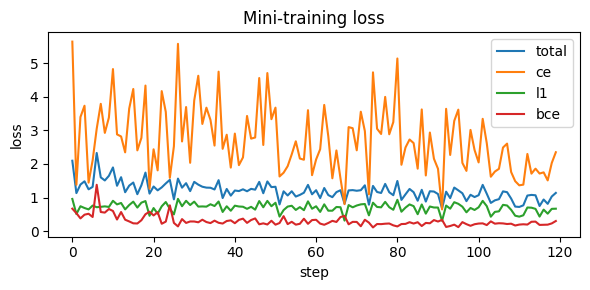

in-distribution tau  pure-parallel (no Markov) : 2.11
in-distribution tau  our re-trained Markov head: 2.85
(a few hundred steps is enough to see the heads learn; the released checkpoint is trained far longer)


In [31]:
# 8.3 did it help? compare tau on the training prompts, Markov heads ON vs OFF
draft.eval(); draft.to(DTYPE)                                # back to 16-bit for inference
plt.figure(figsize=(6, 3))
for i, lab in enumerate(["total", "ce", "l1", "bce"]):
    plt.plot(hist[:, i], label=lab)
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Mini-training loss")
plt.tight_layout(); plt.savefig("assets/train_loss.png", dpi=110); plt.show()

train_pids = [chat_ids(p) for p in SEED_PROMPTS]
tau_trained = np.mean([np.mean(spec_decode_dspark(target, draft, p, max_new=64)[1]["accept_lens"])
                       for p in train_pids])
tau_parallel = np.mean([np.mean(spec_decode_dspark(target, draft, p, max_new=64, use_markov=False)[1]["accept_lens"])
                        for p in train_pids])
print(f"in-distribution tau  pure-parallel (no Markov) : {tau_parallel:.2f}")
print(f"in-distribution tau  our re-trained Markov head: {tau_trained:.2f}")
print("(a few hundred steps is enough to see the heads learn; the released checkpoint is trained far longer)")

### Memory footprint

A quick check that this stayed within a free-tier budget — we never held more than two models at once.

In [32]:
peak = torch.cuda.max_memory_allocated() / 1e9
print(f"peak VRAM used: {peak:.1f} GB  ->  fits a 16 GB T4: {'yes' if peak < 15 else 'tight'}")

peak VRAM used: 12.4 GB  ->  fits a 16 GB T4: yes


## 9. Recap

We rebuilt DSpark from scratch and watched it speed up a real model **without changing its output**:

- **Speculative decoding** trades sequential generation for a cheap draft plus one batched target
  check, with latency $L=(T_{\text{draft}}+T_{\text{verify}})/\tau$.
- **Drafting a whole block** (a parallel backbone that reuses the target's hidden states) keeps
  $T_{\text{draft}}$ from growing with the block; the **Markov head** adds back token-to-token
  dependency, lifting the later positions and raising $\tau$ for almost nothing.
- **The confidence head** predicts which tokens will survive, so we can **truncate the block before
  verifying it** — cutting the target's verification cost per committed token, the lever that matters
  most on a busy, batched server (at batch 1 it's nearly free either way).
- Loading DeepSeek's released weights into our own modules reproduced the behavior and the speedup,
  and the greedy runs matched — the hallmark of a *lossless* method.

The draft we built is tied to the target it was trained for; the same recipe scales up to the much
larger DeepSeek-V4 (Mixture-of-Experts) models in production, where verifying smartly is the
difference between serving one more user or not.

### References
- **DSpark paper** — Cheng et al., *DSpark: Confidence-Scheduled Speculative Decoding with
  Semi-Autoregressive Generation* (Peking University & DeepSeek-AI), distributed as
  [`DSpark_paper.pdf`](https://github.com/deepseek-ai/DeepSpec/blob/main/DSpark_paper.pdf).
- **DeepSpec** — DeepSeek's draft-model training/eval code:
  [github.com/deepseek-ai/DeepSpec](https://github.com/deepseek-ai/DeepSpec).
- **Checkpoints** — [`dspark_qwen3_4b_block7`](https://huggingface.co/deepseek-ai/dspark_qwen3_4b_block7),
  model card [`DeepSeek-V4-Pro-DSpark`](https://huggingface.co/deepseek-ai/DeepSeek-V4-Pro-DSpark).
- **DeepSeek-V4 technical report** — [arXiv:2606.19348](https://arxiv.org/abs/2606.19348).
- **DFlash** — [arXiv:2602.06036](https://arxiv.org/abs/2602.06036); **EAGLE-3** —
  [arXiv:2503.01840](https://arxiv.org/abs/2503.01840).
- **Multi-token prediction & parallel heads** — DeepSeek-V3 MTP
  ([arXiv:2412.19437](https://arxiv.org/abs/2412.19437)); Gloeckle et al.
  ([arXiv:2404.19737](https://arxiv.org/abs/2404.19737)); Medusa, Cai et al.
  ([arXiv:2401.10774](https://arxiv.org/abs/2401.10774)).
- **Speculative-decoding foundations** — Leviathan, Kalman & Matias, *Fast Inference from Transformers
  via Speculative Decoding* ([arXiv:2211.17192](https://arxiv.org/abs/2211.17192)); Chen et al.,
  *Accelerating Large Language Model Decoding with Speculative Sampling*
  ([arXiv:2302.01318](https://arxiv.org/abs/2302.01318)).